### Snow Model Forcing
#### `4_compare_wind_fields.ipynb` 
#### Now, load all other wind fields and compare point simulations of wind speed

Notebook contents 
* this is working directly off of `3_read_wind_ninja_output_ascii.ipynb` to take a look at the output created there 

created by Cassie Lumbrazo\
last updated: Oct 2025\
run location: UAS linux\
python environment: **rasterio**

In [1]:
# import packages 
%matplotlib inline

# plotting packages 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns 

sns.set_theme()
# plt.rcParams['figure.figsize'] = [12,6] #overriding size

# data packages 
import pandas as pd
import numpy as np
import xarray as xr
from datetime import datetime

import scipy

from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
from matplotlib import ticker

# Open Wind Ninja Output
created in `3_read_wind_ninja_output_ascii` notebook

In [88]:
# open the output netcdf 
ds_wn = xr.open_dataset("/hdd/snow_hydrology/wind_ninja/test5/output/windninja_timeseries.nc")
ds_wn.rio.write_crs('EPSG:4326', inplace=True)  # the data is in lat/lon
ds_wn

<xarray.Dataset> Size: 39MB
Dimensions:      (time: 721, y: 78, x: 87)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
  * x            (x) float64 696B 5.238e+05 5.239e+05 ... 5.323e+05 5.324e+05
  * y            (y) float64 624B 6.463e+06 6.463e+06 ... 6.456e+06 6.455e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time, y, x) float32 20MB ...
    wind_dir     (time, y, x) float32 20MB ...

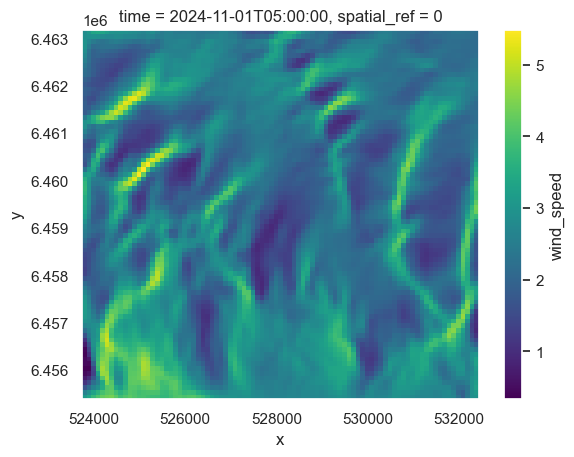

In [121]:
# plot a single timestep 
ds_wn.isel(time=5).wind_speed.plot()

In [90]:
# # Assign latitude and longitude as coordinates for y and x axes
# ds = ds.assign_coords({"y": ds.latitude[:, 0], "x": ds.longitude[0, :]})

# # Now, check the coordinates again to make sure they are assigned properly
# print(ds.coords)

# # Now assign the CRS with EPSG:4326 (assuming the lat/lon are in degrees)
# ds.rio.write_crs("EPSG:4326", inplace=True)

# ds.rio.crs

# Powder Patch Lat/Lon
lat_powderpatch = 58.26200
lon_powderpatch = -134.51700

# select the nearest grid point to the given lat/lon
ds_wn_powderpatch = ds_wn.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

In [91]:
ds_wn_powderpatch

<xarray.Dataset> Size: 12kB
Dimensions:      (time: 721)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    x            float64 8B 5.238e+05
    y            float64 8B 6.455e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time) float32 3kB ...
    wind_dir     (time) float32 3kB ...

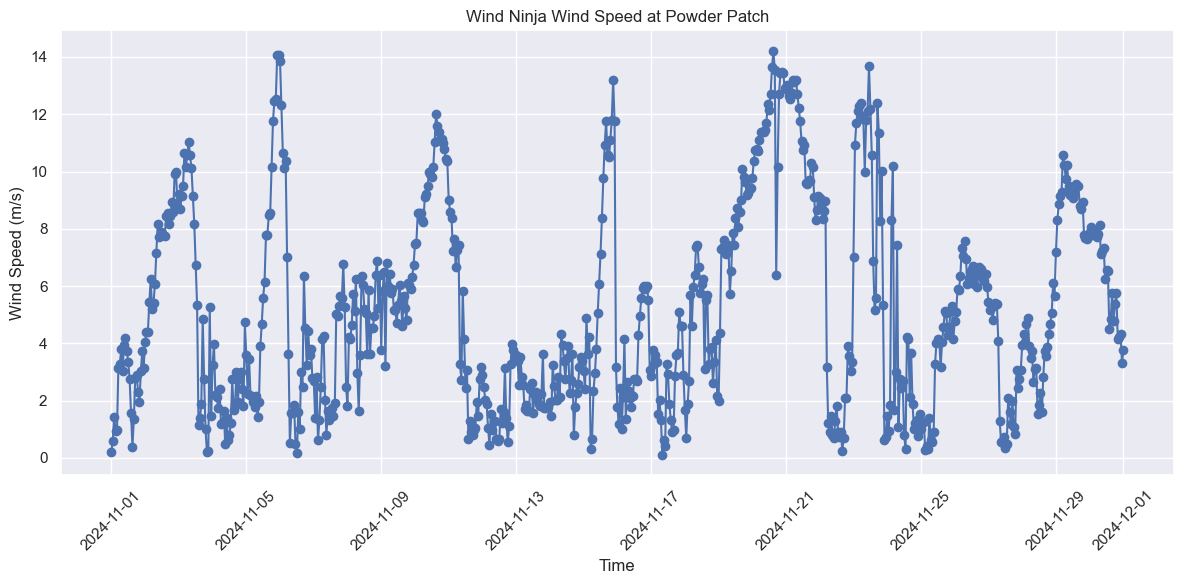

In [92]:
# zoom in the xaxis to see the time series better
plt.figure(figsize=(12, 6))
plt.plot(ds_wn_powderpatch['time'].values, ds_wn_powderpatch['wind_speed'].values, marker='o', linestyle='-', color='b')
plt.title('Wind Ninja Wind Speed at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

# Open the HRRR Input Data 
and then we will bring the wind speed from the tower at Powder Patch and compare them all. 

In [93]:
# read this input file 
hrrr_input_file = "/hdd/snow_hydrology/hrrrak/netcdf/hrrrak_merged_grib_f567_WY2025_test1_utm_1monthonly.nc"

ds_hrrr = xr.open_dataset(hrrr_input_file)
ds_hrrr.rio.write_crs('EPSG:32608', inplace=True)  # the data is in UTM zone 8N
ds_hrrr

<xarray.Dataset> Size: 5MB
Dimensions:                  (time: 721, y: 20, x: 21)
Coordinates:
    step                     (time) timedelta64[ns] 6kB ...
  * time                     (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    valid_time               (time) datetime64[ns] 6kB ...
  * x                        (x) float64 168B 5.039e+05 5.069e+05 ... 5.633e+05
  * y                        (y) float64 160B 6.495e+06 6.492e+06 ... 6.439e+06
    boundaryLayerCloudLayer  float64 8B ...
    spatial_ref              int64 8B 0
Data variables:
    u10                      (time, y, x) float32 1MB ...
    v10                      (time, y, x) float32 1MB ...
    wind_speed               (time, y, x) float32 1MB ...
    wind_direction           (time, y, x) float32 1MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP

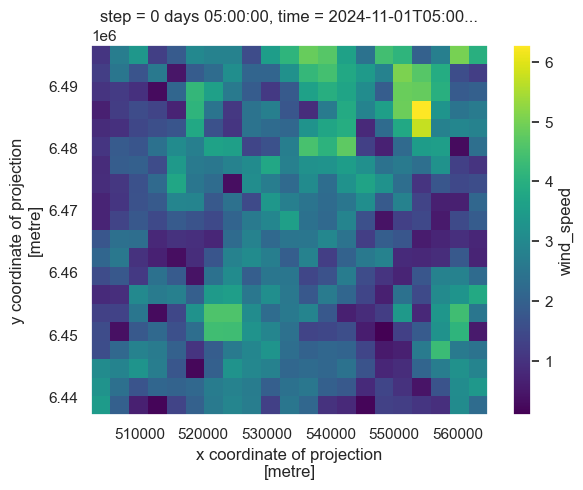

In [129]:
# plot a single timestep 
ds_hrrr.isel(time=5).wind_speed.plot()

Select the Powder Patch Gridcell

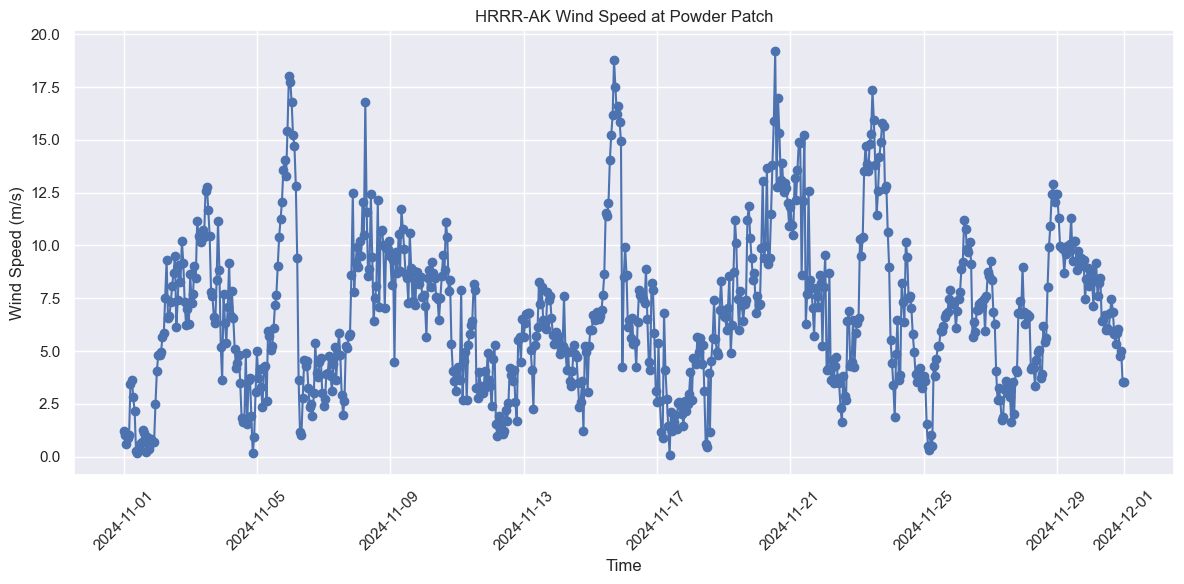

In [94]:
# Powder Patch Lat/Lon
lat_powderpatch = 58.26200
lon_powderpatch = -134.51700

# select the nearest grid point to the given lat/lon
ds_hrrr_pp = ds_hrrr.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

# and plot the timeseries 
plt.figure(figsize=(12, 6))
plt.plot(ds_hrrr_pp['time'].values, ds_hrrr_pp['wind_speed'].values, marker='o', linestyle='-', color='b')
plt.title('HRRR-AK Wind Speed at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

# Compare HRRR and Downscaled Wind Ninja

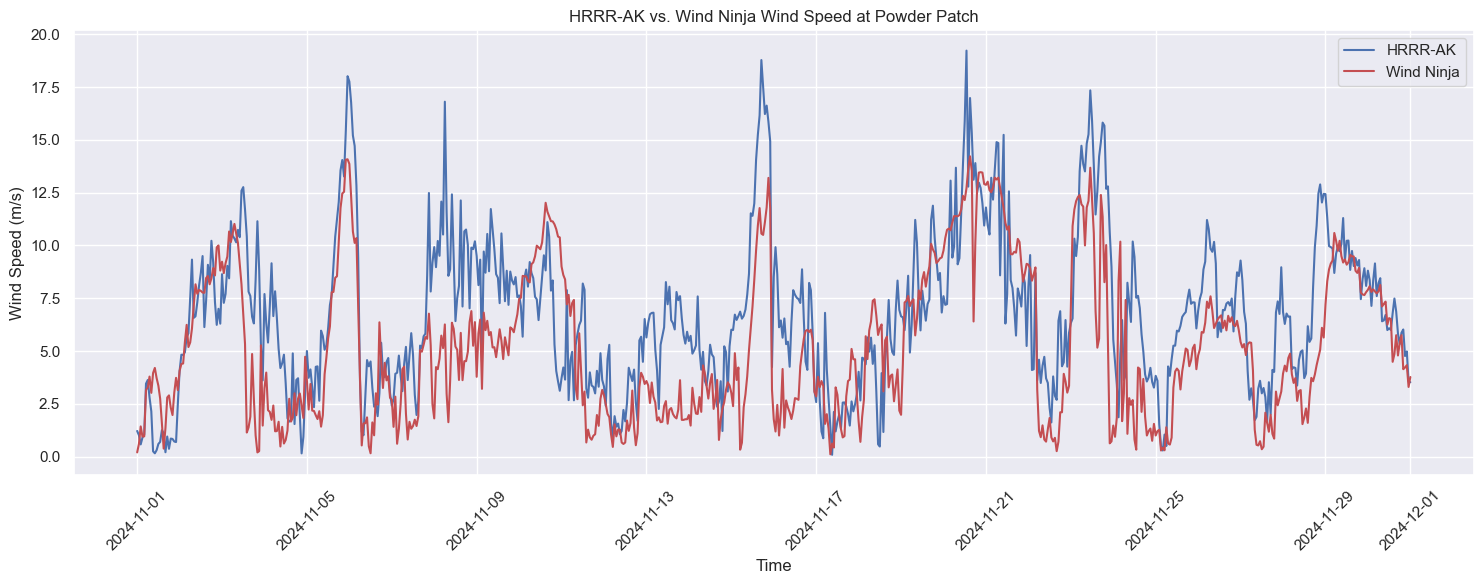

In [105]:
# select the nearest grid point to the given lat/lon
ds_hrrr_pp = ds_hrrr.sel(y=lat_powderpatch, x=lon_powderpatch, method='nearest') 

# and plot the timeseries 
plt.figure(figsize=(15, 6))
# plt.plot(ds_hrrr_pp['time'].values, ds_hrrr_pp['wind_speed'].values, marker='o', linestyle='-', color='b', label='HRRR-AK')
# plt.plot(ds_wn_powderpatch['time'].values, ds_wn_powderpatch['wind_speed'].values, marker='o', linestyle='-', color='r', label='Wind Ninja')

plt.plot(ds_hrrr_pp['time'].values, ds_hrrr_pp['wind_speed'].values, color='b', label='HRRR-AK')
plt.plot(ds_wn_powderpatch['time'].values, ds_wn_powderpatch['wind_speed'].values, color='r', label='Wind Ninja')

plt.title('HRRR-AK vs. Wind Ninja Wind Speed at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

# Compare at Eaglecrest Top

In [ ]:
eaglecrest_station_lat = 58.26174
eaglecrest_station_lon = -134.51173

# select the nearest grid point to the given lat/lon
ds_hrrr_ec = ds_hrrr.sel(y=eaglecrest_station_lat, x=eaglecrest_station_lon, method='nearest') 
ds_wn_ec = ds_wn.sel(y=eaglecrest_station_lat, x=eaglecrest_station_lon, method='nearest') 

In [112]:
ds_wn_ec

<xarray.Dataset> Size: 12kB
Dimensions:      (time: 721)
Coordinates:
  * time         (time) datetime64[ns] 6kB 2024-11-01 ... 2024-12-01
    x            float64 8B 5.238e+05
    y            float64 8B 6.455e+06
    spatial_ref  int64 8B 0
Data variables:
    wind_speed   (time) float32 3kB 0.2 0.6 1.43 0.95 ... 4.22 4.33 3.3 3.77
    wind_dir     (time) float32 3kB ...

In [ ]:
df_met_JECA2_wind_cut


,UDIRZZZ,UPIRZZZ,USIRZZZ
datetime,,,
2024-11-01 00:00:00,137.0,12.0,11.0
2024-11-01 00:01:00,126.0,14.0,13.0
2024-11-01 00:02:00,131.0,14.0,12.0
2024-11-01 00:03:00,136.0,12.0,11.0
2024-11-01 00:04:00,137.0,12.0,10.0
...,...,...,...
2024-12-01 23:55:00,110.0,12.0,10.0
2024-12-01 23:56:00,107.0,13.0,12.0
2024-12-01 23:57:00,109.0,13.0,11.0


In [ ]:
# convert miles per hour to meters per second 
df_met_JECA2_wind_cut['WSPD_mps'] = df_met_JECA2_wind_cut['WSPD'] * 0.44704

/tmp/ipykernel_1134892/3298405868.py:9: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  plt.plot((df_met_JECA2_wind_cut['UPIRZZZ']* 0.44704).resample('H').mean(), color='g', label='JECA2 UPIRZZZ')
/tmp/ipykernel_1134892/3298405868.py:10: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  plt.plot((df_met_JECA2_wind_cut['USIRZZZ']* 0.44704).resample('H').mean(), color='orange', label='JECA2 USIRZZZ')


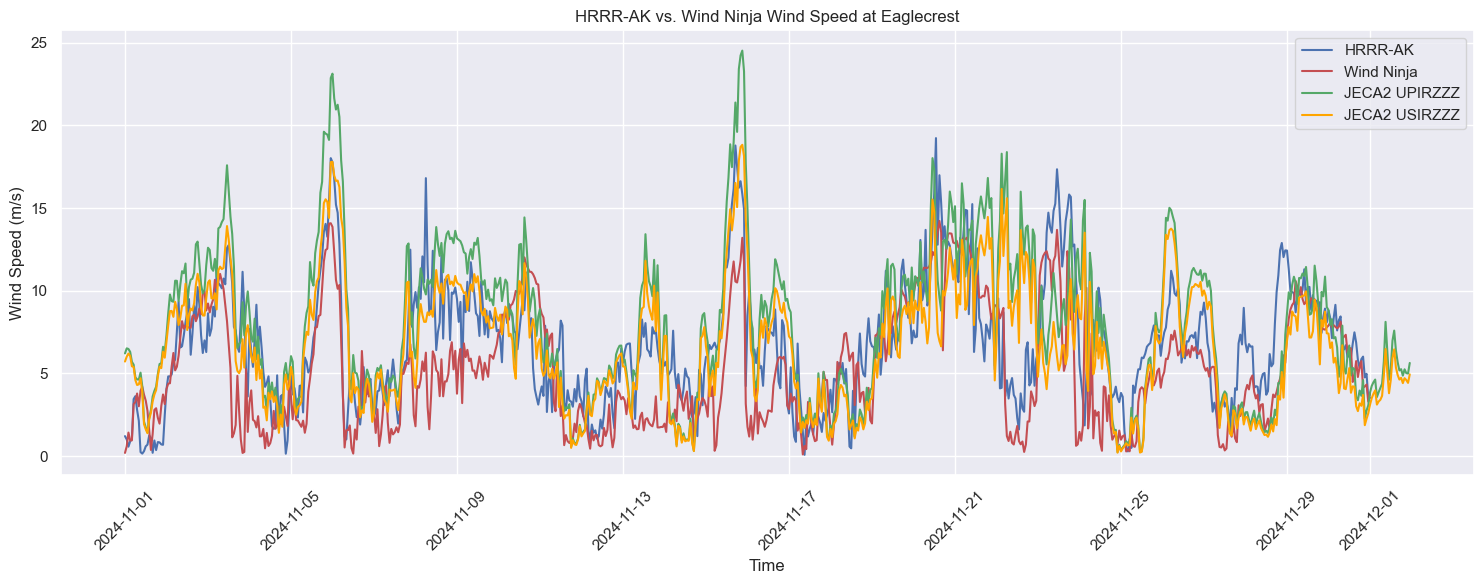

In [130]:
# and plot the timeseries 
plt.figure(figsize=(15, 6))
# plt.plot(ds_hrrr_ec['time'].values, ds_hrrr_ec['wind_speed'].values, marker='o', linestyle='-', color='b', label='HRRR-AK')
# plt.plot(ds_wn_ec['time'].values, ds_wn_ec['wind_speed'].values, marker='o', linestyle='-', color='r', label='Wind Ninja')

plt.plot(ds_hrrr_ec['time'].values, ds_hrrr_ec['wind_speed'].values, color='b', label='HRRR-AK')
plt.plot(ds_wn_ec['time'].values, ds_wn_ec['wind_speed'].values, color='r', label='Wind Ninja')

plt.plot((df_met_JECA2_wind_cut['UPIRZZZ']* 0.44704).resample('H').mean(), color='g', label='JECA2 UPIRZZZ')
plt.plot((df_met_JECA2_wind_cut['USIRZZZ']* 0.44704).resample('H').mean(), color='orange', label='JECA2 USIRZZZ')

plt.title('HRRR-AK vs. Wind Ninja Wind Speed at Eaglecrest')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.legend()
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

# Open the met station datasets from WY2025
we only need the month of Novemeber for now...

In [95]:
# These are the met station data from WY2025
filename = '/home/cassie/data/fishcreek/mesonet/rawdata/DouglasIsland_AllStations_RawData_WY2025_until16March2025.txt'

# open
df_met = pd.read_csv(filename, sep = ",")

# make utc_valid a datetime and index the df_met by it 
df_met['datetime'] = pd.to_datetime(df_met['utc_valid'])
df_met = df_met.set_index('datetime')
# df_met.head()
# list the unique variables in the 'station' column
df_met['station'].unique()

array(['ECEA2', 'ECTA2', 'JECA2', 'NDIA2', 'PPSA2', 'SDIA2'], dtype=object)

In [96]:
# the two most likely sites
df_met_ECEA2 = df_met.where(df_met['station'] == 'ECEA2')
df_met_ECTA2 = df_met.where(df_met['station'] == 'ECTA2')
df_met_JECA2 = df_met.where(df_met['station'] == 'JECA2')

# drop the row if the entire row is nan 
df_met_ECEA2 = df_met_ECEA2.dropna(how='all')
df_met_ECTA2 = df_met_ECTA2.dropna(how='all')
df_met_JECA2 = df_met_JECA2.dropna(how='all')

# drop the column if the entire column is nan 
df_met_ECEA2 = df_met_ECEA2.dropna(axis=1, how='all')
df_met_ECTA2 = df_met_ECTA2.dropna(axis=1, how='all')
df_met_JECA2 = df_met_JECA2.dropna(axis=1, how='all')

# df_met_ECEA2_wind = df_met_ECEA2.filter(regex='^U') # keep only the variables which start with a U 

df_met_ECEA2.head()

,station,utc_valid,PPIRZZZ,TAIRZZZ,XRIRZZZ
datetime,,,,,
2024-10-01 00:04:00,ECEA2,2024-10-01 00:04:00,0.00,37.0,100.0
2024-10-01 00:09:00,ECEA2,2024-10-01 00:09:00,0.00,37.0,100.0
2024-10-01 00:14:00,ECEA2,2024-10-01 00:14:00,0.01,37.0,100.0
2024-10-01 00:19:00,ECEA2,2024-10-01 00:19:00,0.01,37.0,100.0
2024-10-01 00:24:00,ECEA2,2024-10-01 00:24:00,0.01,37.0,100.0


In [97]:
df_met_JECA2_wind = df_met_JECA2.filter(regex='^U') # keep only the variables which start with a U 
df_met_JECA2_wind.head()

,UDIRZZZ,UPIRZZZ,USIRZZZ
datetime,,,
2024-10-01 00:00:00,51.0,37.0,29.0
2024-10-01 00:01:00,37.0,41.0,28.0
2024-10-01 00:02:00,35.0,35.0,31.0
2024-10-01 00:03:00,42.0,41.0,35.0
2024-10-01 00:04:00,36.0,48.0,40.0


<Axes: xlabel='datetime'>

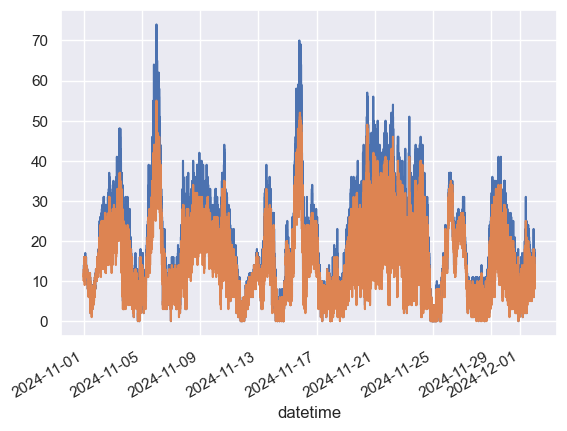

In [98]:
df_met_JECA2_wind_cut['UPIRZZZ'].plot()
df_met_JECA2_wind_cut['USIRZZZ'].plot()

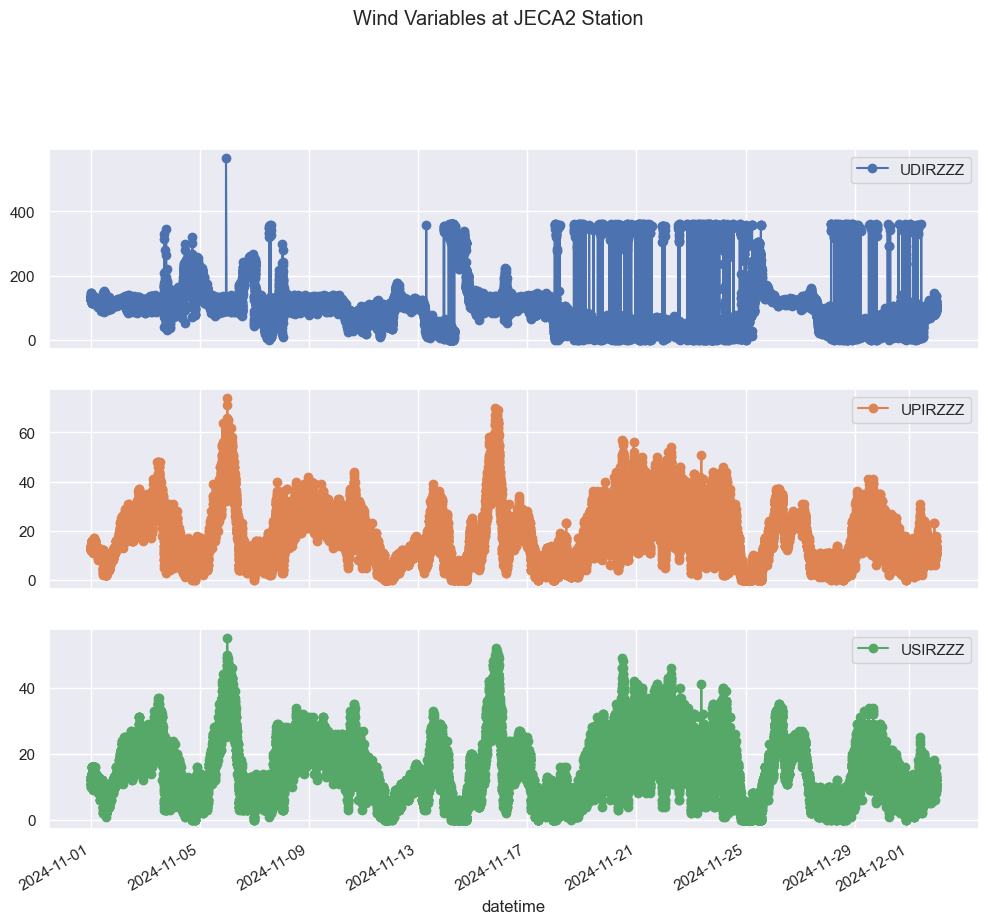

In [99]:
# now cut df_met_JECA2_wind dates to only Nov 2024
df_met_JECA2_wind_cut = df_met_JECA2_wind.loc['2024-11-01':'2024-12-01']

# plot each in it's own subplot 
df_met_JECA2_wind_cut.plot(subplots=True, figsize=(12, 10), marker='o', linestyle='-')
plt.suptitle('Wind Variables at JECA2 Station', y=1.02)
plt.show()

Now, we will compare df_met_JECA2_wind_cut['`USIRZZZ`] with the other wind speeds

In [100]:
eaglecrest_station_lat = 58.26174
eaglecrest_station_lon = -134.51173

In [75]:
df_met_ECTA2_wind = df_met_ECTA2.filter(regex='^U') # keep only the variables which start with a U 
df_met_ECTA2_wind.head()

,UDIRZZZ,UDPRZZZ,UGIRZZZ,UGPRZZZ,UPIRZZZ,UPPRZZZ,URIRZZZ,URPRZZZ,USIRZZZ,USPRZZZ
datetime,,,,,,,,,,
2024-11-09 17:00:00,113.0,NaN,21.0,NaN,42.0,NaN,135.0,NaN,19.0,NaN
2024-11-22 18:00:00,44.0,NaN,29.0,NaN,54.0,NaN,22.0,NaN,25.0,NaN
2024-11-23 18:30:00,45.0,NaN,20.0,NaN,51.0,NaN,0.0,NaN,14.0,NaN
2024-11-24 18:00:00,23.0,NaN,13.0,NaN,45.0,NaN,23.0,NaN,13.0,NaN
2024-11-27 20:00:00,45.0,NaN,14.0,NaN,31.0,NaN,112.0,NaN,4.0,NaN


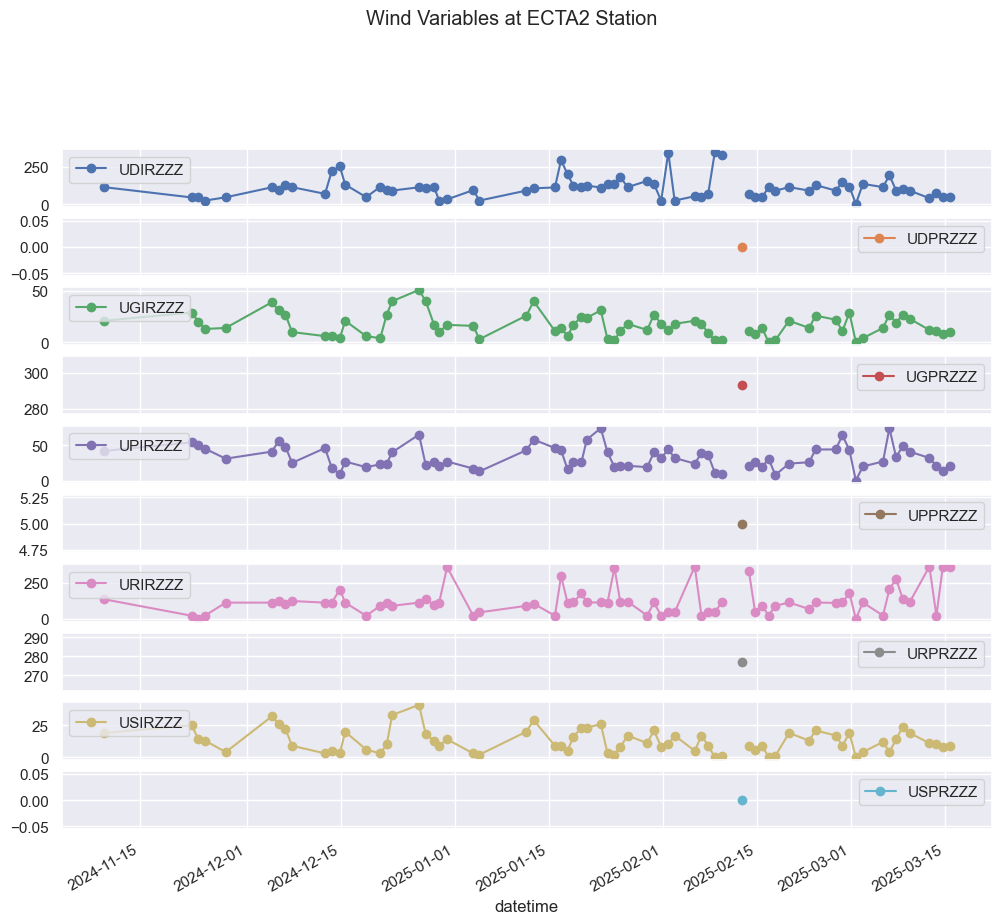

In [ ]:
# plot each in it's own subplot 
df_met_ECTA2_wind.plot(subplots=True, figsize=(12, 10), marker='o', linestyle='-')
plt.suptitle('Wind Variables at ECTA2 Station', y=1.02)
plt.show()

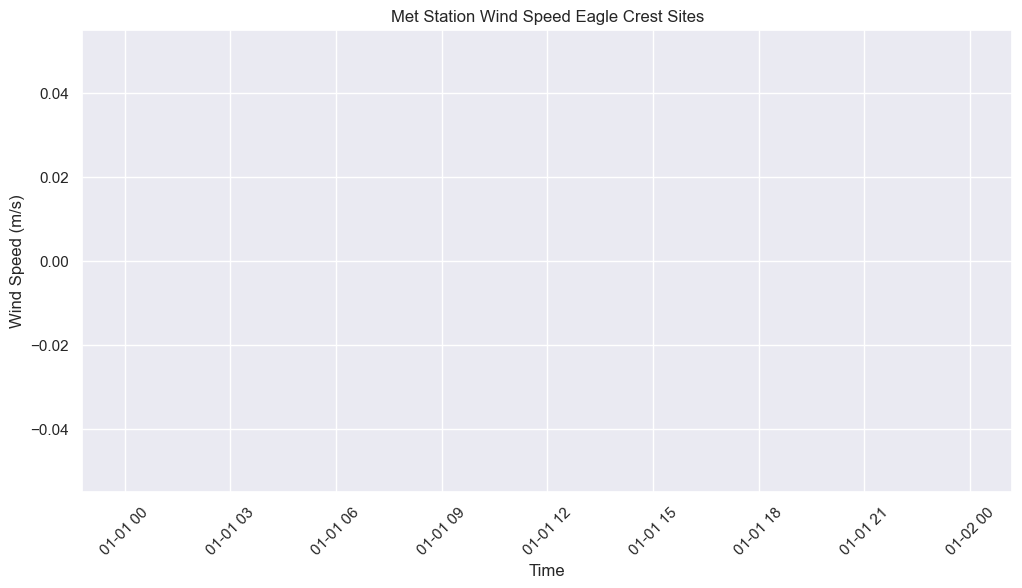

In [14]:
# plot all the US and UD variables, named by the `station` column
plt.figure(figsize=(12, 6))
plt.plot(df_met.index, df_met['USIRZZZ'].where(df_met['station'] == 'ECEA2'), marker='o', linestyle='-', label='USIRZZZ')
plt.plot(df_met.index, df_met['USPRZZZ'].where(df_met['station'] == 'ECEA2'), marker='o', linestyle='-', label='USPRZZZ')
plt.title('Met Station Wind Speed Eagle Crest Sites')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s)')
plt.xticks(rotation=45)
plt.show()

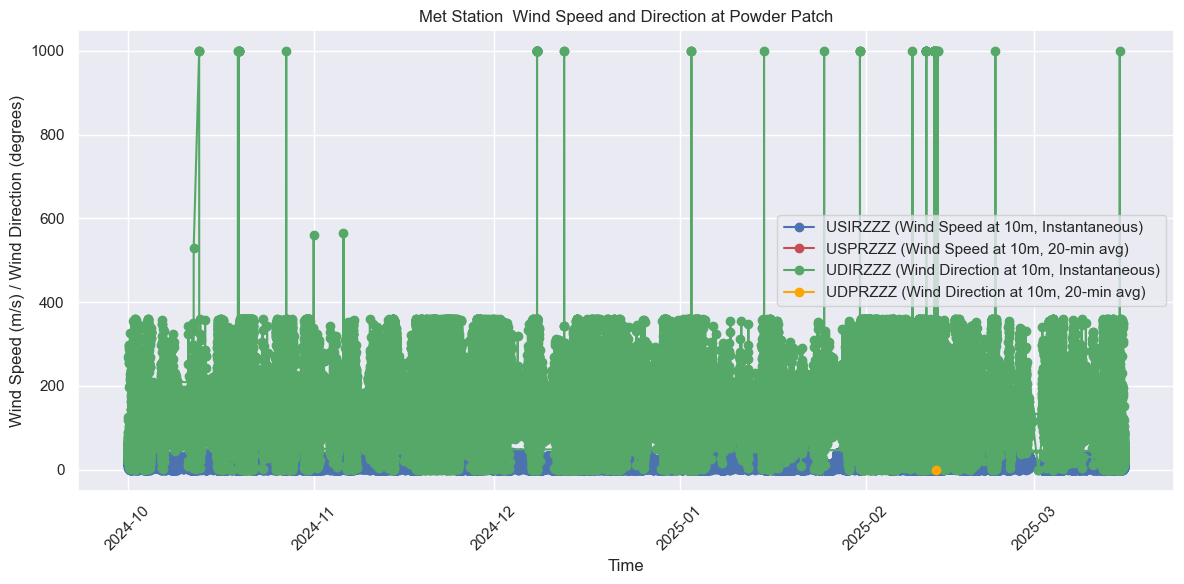

In [11]:
# plot all the US and UD variables in a timeseries
plt.figure(figsize=(12, 6))
plt.plot(df_met.index, df_met['USIRZZZ'], marker='o', linestyle='-', label='USIRZZZ (Wind Speed at 10m, Instantaneous)', color='b')
plt.plot(df_met.index, df_met['USPRZZZ'], marker='o', linestyle='-', label='USPRZZZ (Wind Speed at 10m, 20-min avg)', color='r')
plt.plot(df_met.index, df_met['UDIRZZZ'], marker='o', linestyle='-', label='UDIRZZZ (Wind Direction at 10m, Instantaneous)', color='g')
plt.plot(df_met.index, df_met['UDPRZZZ'], marker='o', linestyle='-', label='UDPRZZZ (Wind Direction at 10m, 20-min avg)', color='orange')
plt.title('Met Station  Wind Speed and Direction at Powder Patch')
plt.xlabel('Time')
plt.ylabel('Wind Speed (m/s) / Wind Direction (degrees)')
plt.legend()
plt.xticks(rotation=45)
# plt.grid(True)
plt.tight_layout()
plt.show()

In [5]:
# All the wind fields are in the US and UD variables
    # 'UD': ['UDIRZZZ', 'UDPRZZZ'],
    # 'UG': ['UGIRZZZ', 'UGPRZZZ'],
    # 'UP': ['UPIRZZZ', 'UPPRZZZ'],
    # 'UR': ['URIRZZZ', 'URPRZZZ'],
    # 'US': ['USIRZZZ', 'USPRZZZ'],